In [8]:
# 1. Autoreload magic
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
import optuna
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
import warnings

In [3]:
# Preprocessor : handle different cardinalities for categorical features

# 1. Be ruthlessly explicit to prevent leaks and overlaps
num_cols = [
    'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 
    'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]
low_cardinality_cols = ['Weekend', 'VisitorType']
high_cardinality_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Month']

# 2. Build the Sub Pipelines 
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_low_pipeline = Pipeline(steps=[
    #('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

cat_high_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('target_encoder', TargetEncoder(target_type='binary', smooth='auto')),
    ('scaler', StandardScaler()) # Essential for TargetEncoder probabilities
])

# 3. Assemble with explicit lists
advanced_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat_low', cat_low_pipeline, low_cardinality_cols),
        ('cat_high', cat_high_pipeline, high_cardinality_cols)
    ],
    remainder='drop' 
)

# 4. The Final Master Pipeline
advanced_pipeline = Pipeline(steps=[
    ('preprocessor', advanced_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])


In [4]:
# loading Online Shoppers Intention DataSet
df=pd.read_csv('../data/raw/online_shoppers_intention.csv')

# Filter out all rows where the Month is 'Feb'
df = df[df['Month'] != 'Feb'].copy()

# Reset the index (Best practice after dropping rows to prevent index alignment bugs later)
df.reset_index(drop=True, inplace=True)

# Separate features (X) and target (y)
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int) # Ensure the target is 0 or 1

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fitting the model
advanced_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Administrative','Administrative_Duration','Informational',..., 'TrafficType','VisitorType','Weekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_low', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [5]:
# threshold recall/precision

# 1. Extract the raw probabilities for Class 1 (Conversion)
# predict_proba returns an array of shape (n_samples, 2): [prob_class_0, prob_class_1]
# We slice [:, 1] to grab only the conversion probabilities
y_probs = advanced_pipeline.predict_proba(X_test)[:, 1]

# 2. Define a range of thresholds to test (e.g., from 0.30 to 0.80)
thresholds = np.arange(0.30, 0.85, 0.05)
results = []

# 3. Loop through each threshold and calculate the new metrics
for thresh in thresholds:
    # If probability >= threshold, predict 1. Otherwise, predict 0.
    y_pred_custom = (y_probs >= thresh).astype(int)
    
    # Calculate metrics (zero_division=0 prevents warnings if a threshold is too high)
    precision = precision_score(y_test, y_pred_custom, zero_division=0)
    recall = recall_score(y_test, y_pred_custom, zero_division=0)
    f1 = f1_score(y_test, y_pred_custom, zero_division=0)
    
    results.append({
        'Threshold': round(thresh, 2),
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1-Score': round(f1, 3)
    })

# 4. Display as a clean DataFrame
threshold_df = pd.DataFrame(results)
display(threshold_df.sort_values(by="F1-Score", ascending=False))

,Threshold,Precision,Recall,F1-Score
6,0.60,0.618,0.694,0.654
7,0.65,0.639,0.661,0.650
5,0.55,0.578,0.738,0.648
8,0.70,0.649,0.612,0.630
4,0.50,0.508,0.760,0.609
9,0.75,0.659,0.566,0.609
3,0.45,0.463,0.811,0.590
10,0.80,0.670,0.516,0.583
2,0.40,0.416,0.855,0.560
1,0.35,0.381,0.899,0.535


In [6]:
# switching to LightGBM

# 2. Assemble the LightGBM Pipeline
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', advanced_preprocessor), # Re-using our exact same preprocessor!
    # class_weight='balanced' works identically here to fight class imbalance
    ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, n_estimators=200))
])

# 3. Fit the beast
lgbm_pipeline.fit(X_train, y_train)

# 4. Extract raw probabilities
lgbm_probs = lgbm_pipeline.predict_proba(X_test)[:, 1]

# 5. Run the threshold loop to map the new Precision/Recall trade-off
lgbm_results = []
for thresh in np.arange(0.30, 0.85, 0.05):
    y_pred_custom = (lgbm_probs >= thresh).astype(int)
    
    precision = precision_score(y_test, y_pred_custom, zero_division=0)
    recall = recall_score(y_test, y_pred_custom, zero_division=0)
    f1 = f1_score(y_test, y_pred_custom, zero_division=0)
    
    lgbm_results.append({
        'Threshold': round(thresh, 2),
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1-Score': round(f1, 3)
    })

# 6. Display the new map
lgbm_threshold_df = pd.DataFrame(lgbm_results)
display(lgbm_threshold_df.sort_values(by="F1-Score", ascending=False))

[LightGBM] [Info] Number of positive: 1539, number of negative: 8177
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2080
[LightGBM] [Info] Number of data points in the train set: 9716, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/home/amarsid/mobile-conversion-pipeline/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Threshold,Precision,Recall,F1-Score
8,0.70,0.695,0.648,0.670
7,0.65,0.660,0.669,0.665
5,0.55,0.617,0.713,0.662
6,0.60,0.630,0.697,0.661
4,0.50,0.594,0.735,0.657
9,0.75,0.724,0.601,0.657
3,0.45,0.568,0.762,0.651
2,0.40,0.539,0.779,0.637
10,0.80,0.758,0.546,0.635
1,0.35,0.510,0.803,0.624


In [10]:
# tuning LightGBM

# Force Optuna to quiet down
optuna.logging.set_verbosity(optuna.logging.WARNING)
# to avoid flooding the screen with warning messages during tuning (cf. pandas feature.names --> array rows after cross_val)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# 1. Define the Optuna Objective Function
def objective(trial):
    # Tell Optuna which hyperparameters to tweak and the ranges to guess within
    params = {
        'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', 100, 500),
        'classifier__learning_rate': trial.suggest_float('classifier__learning_rate', 0.01, 0.2, log=True),
        'classifier__max_depth': trial.suggest_int('classifier__max_depth', 3, 12),
        'classifier__num_leaves': trial.suggest_int('classifier__num_leaves', 20, 150),
        'classifier__min_child_samples': trial.suggest_int('classifier__min_child_samples', 10, 100),
        'classifier__verbosity': -1  # <--- Completely silences the LightGBM chatter
    }
    
    # 2. Rebuild the pipeline with the current trial's parameters
    model = Pipeline(steps=[
        ('preprocessor', advanced_preprocessor), # Re-using our trusted preprocessor
        ('classifier', LGBMClassifier(class_weight='balanced', random_state=42))
    ])
    
    # Inject Optuna's guesses into the pipeline
    model.set_params(**params)
    
    # 3. Cross-validate and return the F1-Score for Optuna to evaluate
    # Using cv=3 keeps the tuning fast; scoring='f1' tells it to focus on Class 1
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    
    return score.mean()

# 4. Create the study and turn it on! 
# (n_trials=20 is a great starting point to see it in action without waiting an hour)
print("Starting Optuna optimization...")
study = optuna.create_study(direction='maximize')

# Add the progress bar flag right here:
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("\n--- Optuna Tuning Complete ---")
print(f"Best F1-Score found: {study.best_value:.3f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Starting Optuna optimization...


  0%|          | 0/3 [00:00<?, ?it/s]


--- Optuna Tuning Complete ---
Best F1-Score found: 0.659
Best Parameters:
  classifier__n_estimators: 325
  classifier__learning_rate: 0.1777164412223499
  classifier__max_depth: 4
  classifier__num_leaves: 46
  classifier__min_child_samples: 55


In [11]:
# 1. Update the pipeline with Optuna's exact findings
optimized_lgbm = Pipeline(steps=[
    ('preprocessor', advanced_preprocessor), 
    ('classifier', LGBMClassifier(
        class_weight='balanced',
        n_estimators=273,
        learning_rate=0.047897,
        max_depth=11,
        num_leaves=49,
        min_child_samples=12,
        random_state=42
    ))
])

# 2. Fit the tuned model
optimized_lgbm.fit(X_train, y_train)

# 3. Extract raw probabilities
opt_probs = optimized_lgbm.predict_proba(X_test)[:, 1]

# 4. Run the threshold loop
opt_results = []
thresholds = np.arange(0.30, 0.85, 0.05)

for thresh in thresholds:
    y_pred_custom = (opt_probs >= thresh).astype(int)
    
    precision = precision_score(y_test, y_pred_custom, zero_division=0)
    recall = recall_score(y_test, y_pred_custom, zero_division=0)
    f1 = f1_score(y_test, y_pred_custom, zero_division=0)
    
    opt_results.append({
        'Threshold': round(thresh, 2),
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1-Score': round(f1, 3)
    })

opt_df = pd.DataFrame(opt_results)
display(opt_df.sort_values(by="F1-Score", ascending=False))

[LightGBM] [Info] Number of positive: 1539, number of negative: 8177
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2082
[LightGBM] [Info] Number of data points in the train set: 9716, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,Threshold,Precision,Recall,F1-Score
5,0.55,0.629,0.708,0.666
4,0.50,0.611,0.730,0.665
6,0.60,0.648,0.683,0.665
2,0.40,0.568,0.779,0.657
3,0.45,0.581,0.751,0.656
8,0.70,0.701,0.609,0.652
7,0.65,0.666,0.637,0.651
1,0.35,0.538,0.790,0.640
9,0.75,0.715,0.568,0.633
10,0.80,0.759,0.541,0.632


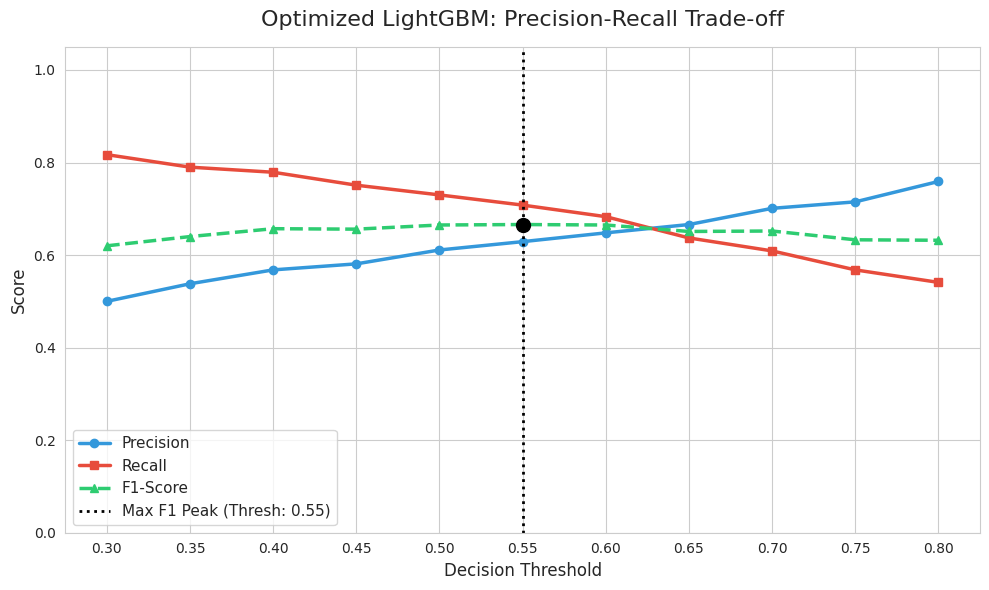

NEW OPTIMAL SWEET SPOT:
Threshold: 0.55
F1-Score:  0.666
Precision: 0.629
Recall:    0.708


In [12]:
# 5. Visualize the new optimal curve
best_idx = opt_df['F1-Score'].idxmax()
best_thresh = opt_df.loc[best_idx, 'Threshold']
best_f1 = opt_df.loc[best_idx, 'F1-Score']
best_prec = opt_df.loc[best_idx, 'Precision']
best_rec = opt_df.loc[best_idx, 'Recall']

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plt.plot(opt_df['Threshold'], opt_df['Precision'], label='Precision', color='#3498db', linewidth=2.5, marker='o')
plt.plot(opt_df['Threshold'], opt_df['Recall'], label='Recall', color='#e74c3c', linewidth=2.5, marker='s')
plt.plot(opt_df['Threshold'], opt_df['F1-Score'], label='F1-Score', color='#2ecc71', linewidth=2.5, linestyle='--', marker='^')

plt.axvline(x=best_thresh, color='black', linestyle=':', linewidth=2, 
            label=f'Max F1 Peak (Thresh: {best_thresh:.2f})')
plt.scatter(best_thresh, best_f1, color='black', s=100, zorder=5)

plt.title('Optimized LightGBM: Precision-Recall Trade-off', fontsize=16, pad=15)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(thresholds)
plt.ylim(0.0, 1.05)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()

print(f"NEW OPTIMAL SWEET SPOT:")
print(f"Threshold: {best_thresh:.2f}")
print(f"F1-Score:  {best_f1:.3f}")
print(f"Precision: {best_prec:.3f}")
print(f"Recall:    {best_rec:.3f}")

In [ ]:
# visualize the feature importance

# 1. Rebuild and fit the absolute best pipeline on the full training data
best_params = study.best_params
# Ensure the verbosity stays muted
best_params['classifier__verbosity'] = -1  

final_model = Pipeline(steps=[
    ('preprocessor', advanced_preprocessor),
    ('classifier', LGBMClassifier(class_weight='balanced', random_state=42))
])

# Strip the 'classifier__' prefix from the keys so LGBMClassifier accepts them directly
lgbm_params = {k.split('__')[1]: v for k, v in best_params.items()}
final_model.named_steps['classifier'].set_params(**lgbm_params)

# Fit on the entire training set
final_model.fit(X_train, y_train)

# 2. Extract the transformed feature names out of the ColumnTransformer
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# 3. Grab the raw feature importances from LightGBM
importances = final_model.named_steps['classifier'].feature_importances_

# 4. Pair them up into a beautifully sorted DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Plot the Top 15 drivers of online conversion
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df.head(15), 
    palette='viridis'
)
plt.title('Top 15 Features Driving Customer Conversion Decisions', fontsize=14, pad=15)
plt.xlabel('Feature Importance Score (Split Count)', fontsize=12)
plt.ylabel('Engineered Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# partial dependencies
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# 1. Identify the original raw column names to evaluate
target_features = ['ExitRates', 'ProductRelated_Duration', 'PageValues']

# 2. Let scikit-learn build the grid automatically (removes the conflict)
display = PartialDependenceDisplay.from_estimator(
    final_model,            # Your fitted best pipeline
    X_train,                # Raw training DataFrame
    features=target_features,
    response_method='predict_proba' # Plot probability scores (0.0 to 1.0)
)

# 3. Resize the figure after scikit-learn creates it
fig = display.figure_
fig.set_size_inches(15, 5)

# 4. Polish the layout using the dynamically generated axes
for a in display.axes_.flatten():
    if a is not None:
        a.grid(True, linestyle='--', alpha=0.6)
        a.set_ylabel('Partial Dependence (Prob Class 1)', fontsize=10)

plt.suptitle('Partial Dependence of Conversion Probability', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()